In [ ]:
import numpy as np
import torch    
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
#X_raw = np.load('X_raw.npy')
#X_feat = np.load('X_feat.npy')
X_feat_12 = np.load('X_feat_12.npy')
Y = np.load('Y.npy')


# Mismo random_state para que el test sea idéntico en ambos
#X_train_raw,  X_test_raw,  Y_train, Y_test = train_test_split(X_raw,  Y, test_size=0.2, random_state=42)
#X_train_feat, X_test_feat, _,       _      = train_test_split(X_feat, Y, test_size=0.2, random_state=42)
X_train_feat_12, X_test_feat_12, Y_train, Y_test = train_test_split(X_feat_12, Y, test_size=0.2, random_state=42)
"""
scaler_raw  = StandardScaler()
X_train_raw  = scaler_raw.fit_transform(X_train_raw)
X_test_raw   = scaler_raw.transform(X_test_raw)

scaler_feat = StandardScaler()
X_train_feat = scaler_feat.fit_transform(X_train_feat)
X_test_feat  = scaler_feat.transform(X_test_feat)

print(f"Shape X_raw:  {X_raw.shape}")
print(f"Shape X_feat: {X_feat.shape}")

print(f"Raw  → train: {X_train_raw.shape}  | test: {X_test_raw.shape}")
print(f"Feat → train: {X_train_feat.shape} | test: {X_test_feat.shape}")
"""
scaler_feat_12 = StandardScaler()
X_train_feat_12 = scaler_feat_12.fit_transform(X_train_feat_12)
X_test_feat_12  = scaler_feat_12.transform(X_test_feat_12)
print(f"Shape X_feat_12: {X_feat_12.shape}")
print(f"Feat_12 → train: {X_train_feat_12.shape} | test: {X_test_feat_12.shape}")

Shape X_raw:  (16984, 3002)
Shape X_feat: (16984, 40)
Raw  → train: (13587, 3002)  | test: (3397, 3002)
Feat → train: (13587, 40) | test: (3397, 40)


In [3]:
ENFERMEDADES = ['NORM', 'STTC', 'CD', 'MI', 'HYP']

In [10]:
import numpy as np

for i in range(Y.shape[1]):
    num_ones = np.sum(Y[:, i] == 1)
    num_zeros = np.sum(Y[:, i] == 0)
    
    print(f"Enfermedad {ENFERMEDADES[i]}: {num_ones+num_zeros}")
    print(f"  1s (positivos): {num_ones}")
    print(f"  0s (negativos): {num_zeros}")
    print()

Enfermedad NORM: 16984
  1s (positivos): 4157
  0s (negativos): 12827

Enfermedad STTC: 16984
  1s (positivos): 7132
  0s (negativos): 9852

Enfermedad CD: 16984
  1s (positivos): 4339
  0s (negativos): 12645

Enfermedad MI: 16984
  1s (positivos): 2145
  0s (negativos): 14839

Enfermedad HYP: 16984
  1s (positivos): 3868
  0s (negativos): 13116



In [5]:
def mostrar_matrices(nombre, Y_true, Y_pred):
    mcm = multilabel_confusion_matrix(Y_true, Y_pred)
    fig, axes = plt.subplots(1, len(ENFERMEDADES), figsize=(4 * len(ENFERMEDADES), 4))
    fig.suptitle(f"Matrices de confusión — {nombre}", fontsize=13)
    for i, (ax, clase) in enumerate(zip(axes, ENFERMEDADES)):
        tn, fp, fn, tp = mcm[i].ravel()
        matriz = np.array([[tp, fn], [fp, tn]])
        ax.imshow(matriz, cmap='Blues')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Pred Pos', 'Pred Neg'], fontsize=9)
        ax.set_yticklabels(['Real Pos', 'Real Neg'], fontsize=9)
        ax.set_title(clase, fontsize=11)
        for row in range(2):
            for col in range(2):
                ax.text(col, row, str(matriz[row, col]),
                        ha='center', va='center', fontsize=12,
                        color='white' if matriz[row, col] > matriz.max() / 2 else 'black')
    plt.tight_layout()
    plt.show()

In [ ]:
def ejecutar_logistic_regression(X_train, X_test, Y_train, Y_test, nombre):
    print(f"\n=== Logistic Regression — {nombre} ===")
    model = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced'), n_jobs=-1)
    model.fit(X_train, Y_train)
    print("\n--- Train ---")
    print(classification_report(Y_train, model.predict(X_train), zero_division=0, target_names=ENFERMEDADES))
    print("--- Test ---")
    print(classification_report(Y_test, model.predict(X_test), zero_division=0, target_names=ENFERMEDADES))
    mostrar_matrices(f"LR — {nombre}", Y_test, model.predict(X_test))
    return model


def ejecutar_random_forest(X_train, X_test, Y_train, Y_test, nombre):
    print(f"\n=== Random Forest — {nombre} ===")
    model = RandomForestClassifier(n_estimators=200,max_depth=20,min_samples_leaf=5, random_state=42, class_weight='balanced',n_jobs=-1)
    model.fit(X_train, Y_train)
    print("\n--- Train ---")
    print(classification_report(Y_train, model.predict(X_train), zero_division=0, target_names=ENFERMEDADES))
    print("--- Test ---")
    print(classification_report(Y_test, model.predict(X_test), zero_division=0, target_names=ENFERMEDADES))
    mostrar_matrices(f"RF — {nombre}", Y_test, model.predict(X_test))
    return model


def ejecutar_mlp(X_train, X_test, Y_train, Y_test, nombre):
    print(f"\n=== MLP — {nombre} ===")

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
    Y_train_t = torch.tensor(Y_train, dtype=torch.float32)

    train_loader      = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=32, shuffle=True)
    train_eval_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=32, shuffle=False)
    test_loader       = DataLoader(TensorDataset(X_test_t, torch.zeros(len(X_test_t))), batch_size=32, shuffle=False)

    total      = Y_train.shape[0]
    pos_counts = Y_train.sum(axis=0)
    neg_counts = total - pos_counts
    pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-8), dtype=torch.float32)

    class MLP(nn.Module):
        def __init__(self, input_size, output_size):
            super().__init__()
            self.red = nn.Sequential(
                nn.Linear(input_size, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.3), #No overfitting
                nn.Linear(256, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(64, output_size)
            )
        def forward(self, x):
            return self.red(x)

    model     = MLP(input_size=X_train.shape[1], output_size=Y_train.shape[1])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    EPOCHS    = 100
    PACIENCIA = 15
    mejor_perdida     = float('inf')
    epochs_sin_mejora = 0
    mejor_estado      = None

    for epoch in range(EPOCHS):
        model.train()
        perdida_total = 0
        for X_batch, Y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), Y_batch)
            loss.backward()
            optimizer.step()
            perdida_total += loss.item()

        perdida_media = perdida_total / len(train_loader)
        scheduler.step(perdida_media)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS} - Pérdida: {perdida_media:.4f} - lr: {optimizer.param_groups[0]['lr']:.6f}")

        if perdida_media < mejor_perdida - 0.001:
            mejor_perdida     = perdida_media
            epochs_sin_mejora = 0
            mejor_estado      = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_sin_mejora += 1
            if epochs_sin_mejora >= PACIENCIA:
                print(f"  Early stopping en epoch {epoch+1}")
                break

    model.load_state_dict(mejor_estado)
    model.eval()


    def predecir(loader):
        preds = []
        with torch.no_grad():
            for X_batch, _ in loader:
                preds.append((torch.sigmoid(model(X_batch)) >= 0.5).float())
        return torch.cat(preds).numpy()

    Y_pred_train = predecir(train_eval_loader)
    Y_pred_test  = predecir(test_loader)

    
    print("\n--- Train ---")
    print(classification_report(Y_train, Y_pred_train, zero_division=0, target_names=ENFERMEDADES))
    print("--- Test ---")
    print(classification_report(Y_test, Y_pred_test, zero_division=0, target_names=ENFERMEDADES))
    mostrar_matrices(f"MLP — {nombre}", Y_test, Y_pred_test)
    return model


=== Logistic Regression — Megavector ===

--- Train ---
              precision    recall  f1-score   support

        NORM       0.63      0.86      0.73      3323
        STTC       0.80      0.87      0.83      5711
          CD       0.57      0.82      0.67      3447
          MI       0.46      0.88      0.60      1729
         HYP       0.56      0.81      0.66      3111

   micro avg       0.62      0.85      0.72     17321
   macro avg       0.60      0.85      0.70     17321
weighted avg       0.64      0.85      0.73     17321
 samples avg       0.65      0.82      0.70     17321

--- Test ---
              precision    recall  f1-score   support

        NORM       0.42      0.63      0.51       834
        STTC       0.66      0.73      0.70      1421
          CD       0.40      0.57      0.47       892
          MI       0.22      0.47      0.30       416
         HYP       0.35      0.56      0.43       757

   micro avg       0.44      0.62      0.51      4320
   macr

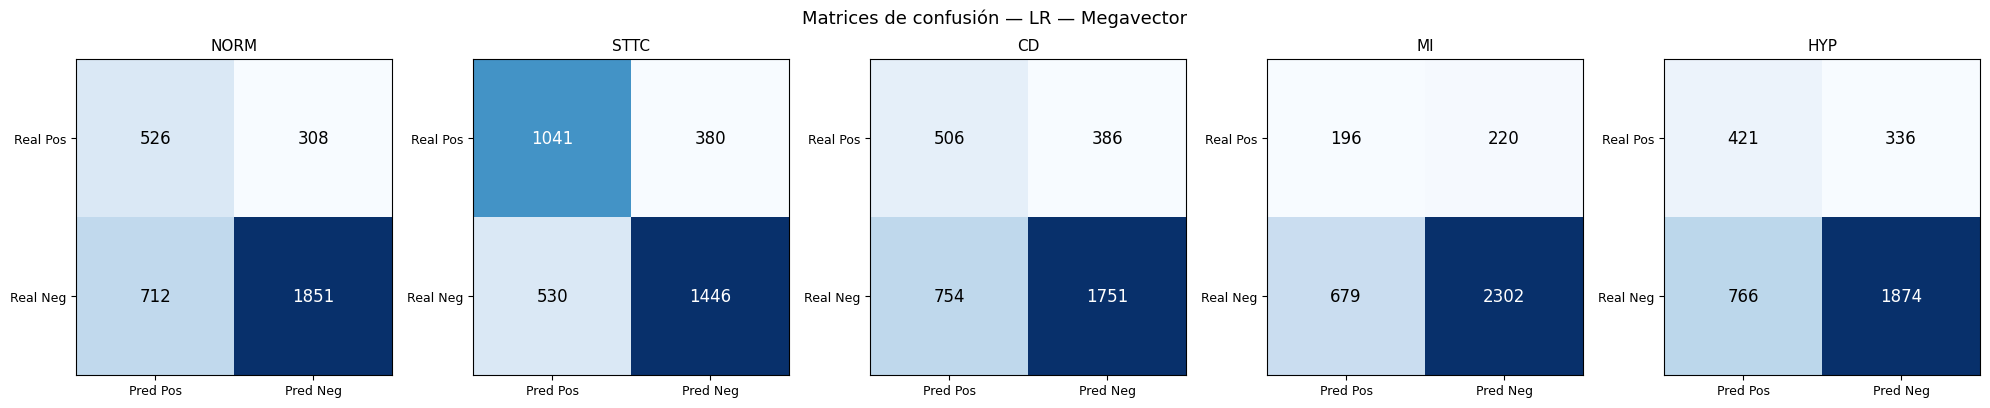


=== Logistic Regression — Features ===

--- Train ---
              precision    recall  f1-score   support

        NORM       0.50      0.81      0.62      3323
        STTC       0.72      0.83      0.78      5711
          CD       0.43      0.72      0.53      3447
          MI       0.29      0.70      0.41      1729
         HYP       0.49      0.65      0.56      3111

   micro avg       0.50      0.76      0.61     17321
   macro avg       0.49      0.74      0.58     17321
weighted avg       0.54      0.76      0.62     17321
 samples avg       0.56      0.74      0.61     17321

--- Test ---
              precision    recall  f1-score   support

        NORM       0.48      0.78      0.60       834
        STTC       0.72      0.83      0.77      1421
          CD       0.43      0.72      0.54       892
          MI       0.27      0.69      0.39       416
         HYP       0.49      0.65      0.56       757

   micro avg       0.50      0.75      0.60      4320
   macro 

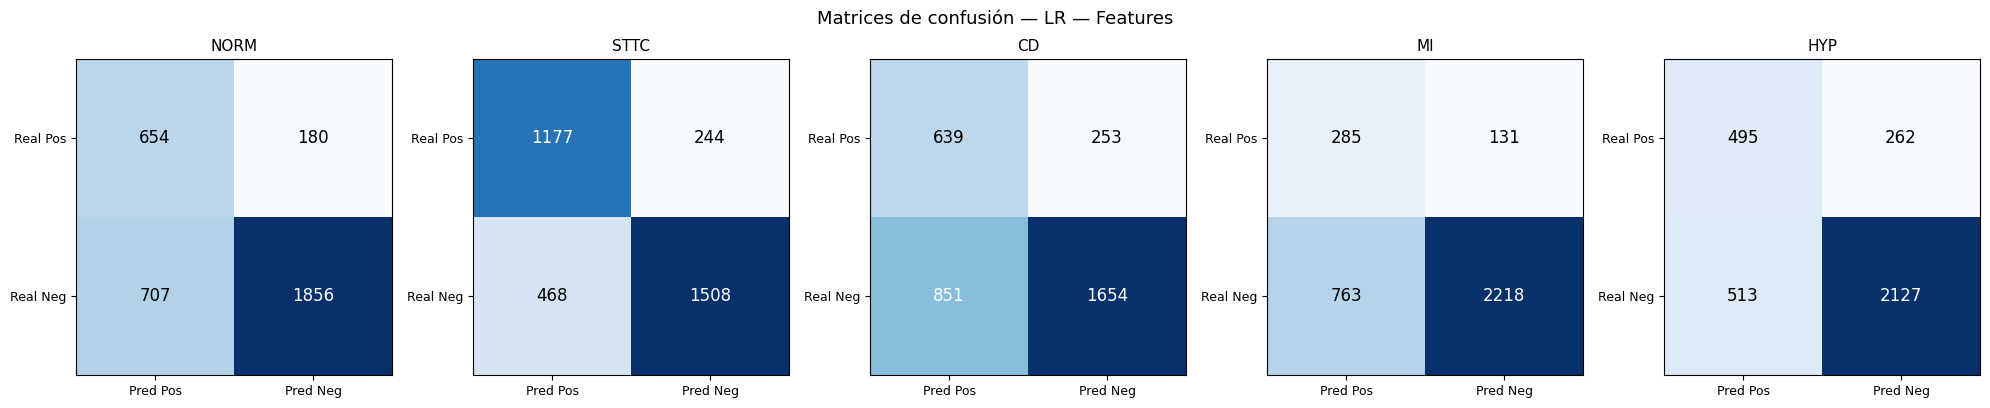

In [ ]:
#lr_raw  = ejecutar_logistic_regression(X_train_raw,  X_test_raw,  Y_train, Y_test, "Megavector")
#lr_feat = ejecutar_logistic_regression(X_train_feat, X_test_feat, Y_train, Y_test, "Features")
lr_feat_12 = ejecutar_logistic_regression(X_train_feat_12, X_test_feat_12, Y_train, Y_test, "Features_12")


=== Random Forest — Megavector ===

--- Train ---
              precision    recall  f1-score   support

        NORM       0.86      0.89      0.88      3323
        STTC       0.97      0.75      0.85      5711
          CD       0.97      0.85      0.90      3447
          MI       0.88      0.91      0.90      1729
         HYP       0.96      0.83      0.89      3111

   micro avg       0.93      0.83      0.88     17321
   macro avg       0.93      0.85      0.88     17321
weighted avg       0.94      0.83      0.88     17321
 samples avg       0.76      0.77      0.76     17321

--- Test ---
              precision    recall  f1-score   support

        NORM       0.58      0.60      0.59       834
        STTC       0.79      0.56      0.65      1421
          CD       0.56      0.33      0.41       892
          MI       0.48      0.32      0.38       416
         HYP       0.77      0.38      0.50       757

   micro avg       0.66      0.46      0.54      4320
   macro avg 

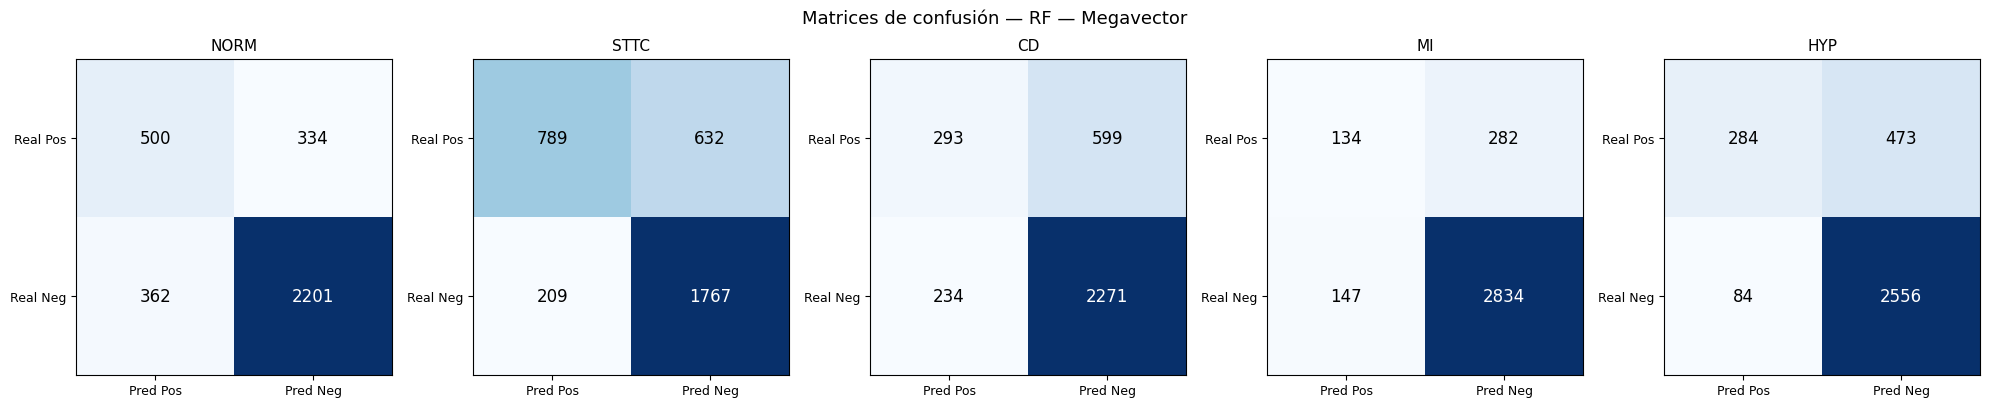


=== Random Forest — Features ===

--- Train ---
              precision    recall  f1-score   support

        NORM       0.77      0.86      0.81      3323
        STTC       0.98      0.68      0.80      5711
          CD       0.90      0.79      0.84      3447
          MI       0.77      0.89      0.82      1729
         HYP       0.89      0.78      0.83      3111

   micro avg       0.87      0.78      0.82     17321
   macro avg       0.86      0.80      0.82     17321
weighted avg       0.89      0.78      0.82     17321
 samples avg       0.69      0.71      0.69     17321

--- Test ---
              precision    recall  f1-score   support

        NORM       0.56      0.65      0.60       834
        STTC       0.84      0.54      0.66      1421
          CD       0.56      0.40      0.46       892
          MI       0.46      0.41      0.43       416
         HYP       0.72      0.48      0.57       757

   micro avg       0.65      0.51      0.57      4320
   macro avg   

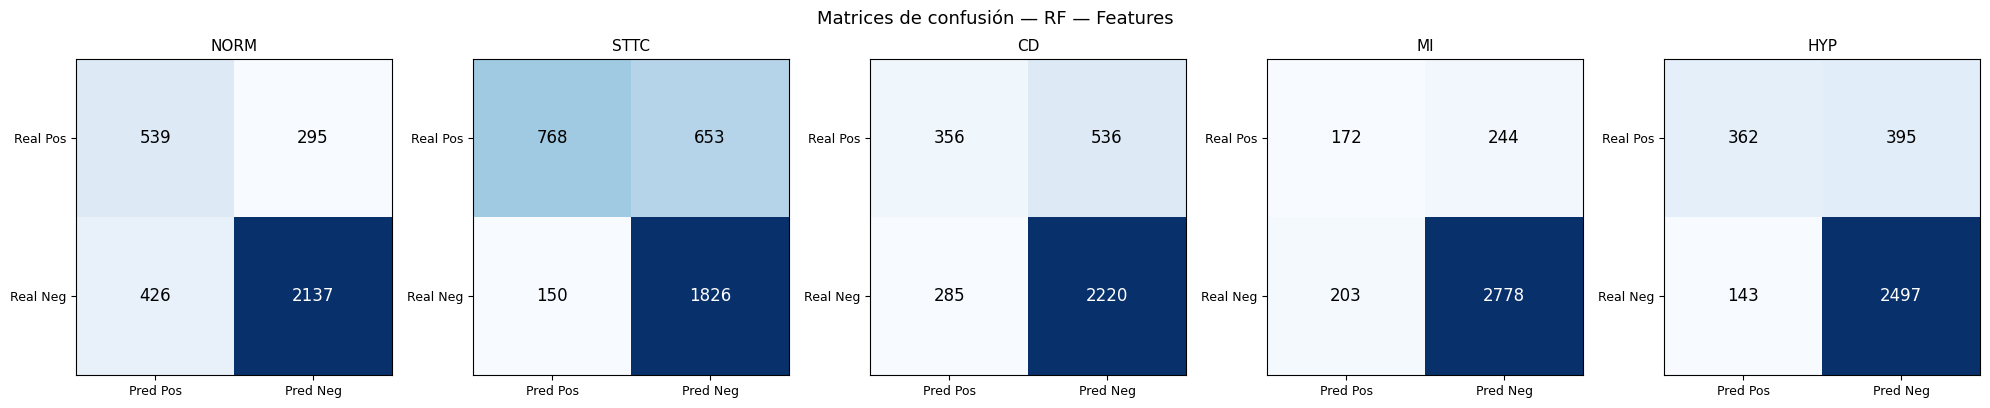

In [ ]:
#rf_raw  = ejecutar_random_forest(X_train_raw,  X_test_raw,  Y_train, Y_test, "Megavector")
#rf_feat = ejecutar_random_forest(X_train_feat, X_test_feat, Y_train, Y_test, "Features")
rf_feat_12 = ejecutar_random_forest(X_train_feat_12, X_test_feat_12, Y_train, Y_test, "Features_12")


=== MLP — Megavector ===
  Epoch 10/100 - Pérdida: 0.7505 - lr: 0.001000
  Epoch 20/100 - Pérdida: 0.6971 - lr: 0.001000
  Epoch 30/100 - Pérdida: 0.6547 - lr: 0.001000
  Epoch 40/100 - Pérdida: 0.6211 - lr: 0.001000
  Epoch 50/100 - Pérdida: 0.5871 - lr: 0.001000
  Epoch 60/100 - Pérdida: 0.5637 - lr: 0.001000
  Epoch 70/100 - Pérdida: 0.5348 - lr: 0.001000
  Epoch 80/100 - Pérdida: 0.5262 - lr: 0.001000
  Epoch 90/100 - Pérdida: 0.4967 - lr: 0.001000
  Epoch 100/100 - Pérdida: 0.4800 - lr: 0.001000

--- Train ---
              precision    recall  f1-score   support

        NORM       0.75      0.96      0.84      3323
        STTC       0.90      0.97      0.94      5711
          CD       0.60      0.96      0.74      3447
          MI       0.59      0.99      0.74      1729
         HYP       0.75      0.91      0.82      3111

   micro avg       0.74      0.96      0.83     17321
   macro avg       0.72      0.96      0.82     17321
weighted avg       0.76      0.96      0.84 

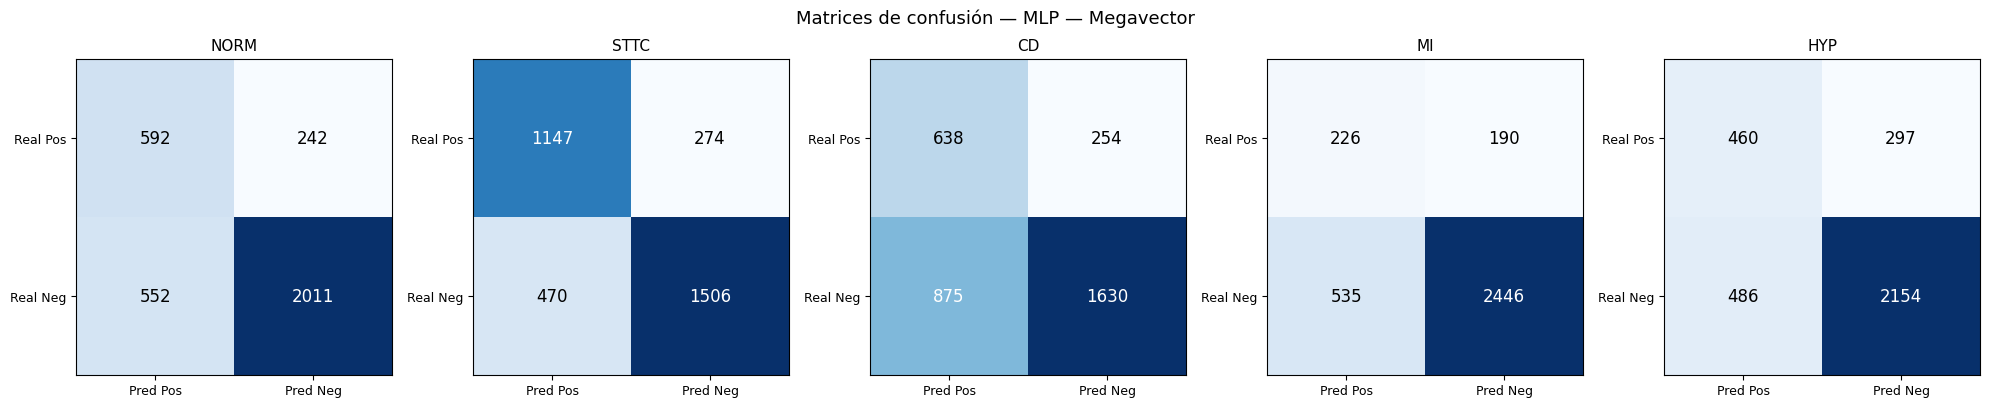


=== MLP — Features ===
  Epoch 10/100 - Pérdida: 0.7634 - lr: 0.001000
  Epoch 20/100 - Pérdida: 0.7489 - lr: 0.001000
  Epoch 30/100 - Pérdida: 0.7402 - lr: 0.001000
  Epoch 40/100 - Pérdida: 0.7304 - lr: 0.001000
  Epoch 50/100 - Pérdida: 0.7257 - lr: 0.001000
  Epoch 60/100 - Pérdida: 0.7189 - lr: 0.001000
  Epoch 70/100 - Pérdida: 0.7035 - lr: 0.000500
  Epoch 80/100 - Pérdida: 0.6996 - lr: 0.000500
  Epoch 90/100 - Pérdida: 0.6954 - lr: 0.000250
  Epoch 100/100 - Pérdida: 0.6854 - lr: 0.000125

--- Train ---
              precision    recall  f1-score   support

        NORM       0.59      0.85      0.69      3323
        STTC       0.73      0.93      0.82      5711
          CD       0.51      0.79      0.62      3447
          MI       0.37      0.84      0.52      1729
         HYP       0.56      0.72      0.63      3111

   micro avg       0.57      0.84      0.68     17321
   macro avg       0.55      0.83      0.66     17321
weighted avg       0.59      0.84      0.69   

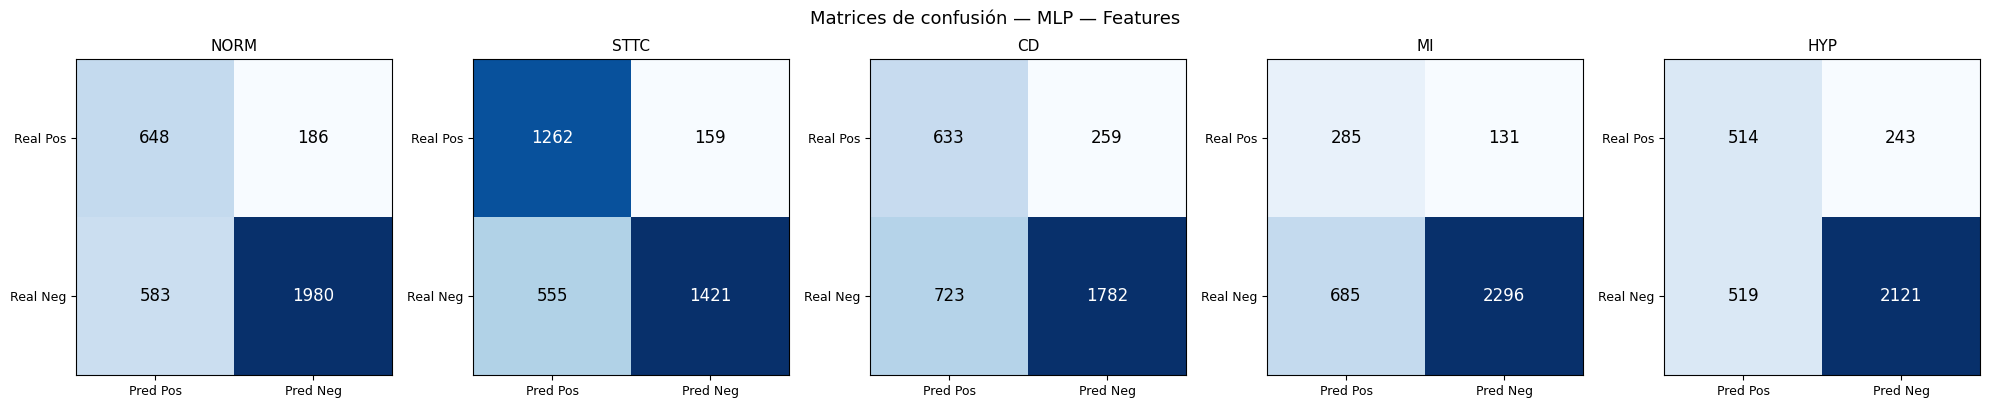

In [ ]:
#mlp_raw  = ejecutar_mlp(X_train_raw,  X_test_raw,  Y_train, Y_test, "Megavector")
#mlp_feat = ejecutar_mlp(X_train_feat, X_test_feat, Y_train, Y_test, "Features")
mlp_feat_12 = ejecutar_mlp(X_train_feat_12, X_test_feat_12, Y_train, Y_test, "Features_12")